# Práctica 4 — Comparación Gini vs Entropía
## nivel_escolaridad: concentración de frecuencias y diversidad categórica
**Jesús y Emiliano** · ENDIREH 2021

Tema sensible: los datos representan experiencias reales. Las categorías
no deben leerse como juicios sobre personas o grupos.

Variable elegida para la comparación: nivel_escolaridad.
Razón: es la única categórica con 6 categorías estables. sufrio_violencia_pareja
es binaria y haría trivial la comparación.

In [1]:
import sys
from pathlib import Path
import json

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from config.rutas import RUTA_PARQUET_LIMPIO, RUTA_FIGURAS, RUTA_TABLAS
from src.heterogeneidad import gini_simpson, iqv, entropia_shannon, entropia_maxima
from src.concentracion import gini_sobre_frecuencias

sns.set_theme(style="whitegrid")

In [2]:
df = pl.read_parquet(RUTA_PARQUET_LIMPIO)
conteos = (
    df.group_by("nivel_escolaridad")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
conteos

nivel_escolaridad,n
cat,u32
"""a1""",61669
"""c1""",14425
"""b1""",12546
"""b2""",9497
"""c2""",4765
"""a2""",2394


In [3]:
g   = gini_sobre_frecuencias(conteos["n"])
gs  = gini_simpson(conteos["n"])
q   = iqv(conteos["n"])
h   = entropia_shannon(conteos["n"])
hmax = entropia_maxima(conteos.height)

print(f"Gini sobre frecuencias : {g:.4f}")
print(f"Gini-Simpson           : {gs:.4f}")
print(f"IQV                    : {q:.4f}")
print(f"Shannon (bits)         : {h:.4f} / {hmax:.4f}")

Gini sobre frecuencias : 0.5198
Gini-Simpson           : 0.6133
IQV                    : 0.7360
Shannon (bits)         : 1.8499 / 2.5850


In [4]:
res = {
    "variable": "nivel_escolaridad",
    "k": conteos.height,
    "gini_frecuencias": float(g),
    "gini_simpson": float(gs),
    "iqv": float(q),
    "shannon_bits": float(h),
    "shannon_max": float(hmax),
    "shannon_rel": float(h / hmax),
}
with open(RUTA_TABLAS / "resultados_sintesis.json", "w") as f:
    json.dump(res, f, indent=2, ensure_ascii=False)
res

{'variable': 'nivel_escolaridad',
 'k': 6,
 'gini_frecuencias': 0.5198108190244644,
 'gini_simpson': 0.6133235298350173,
 'iqv': 0.7359882358020207,
 'shannon_bits': 1.849858017576307,
 'shannon_max': 2.584962500721156,
 'shannon_rel': 0.7156227670847184}

### Síntesis

El coeficiente de Gini aplicado a las frecuencias de nivel_escolaridad es
___. La entropía de Shannon sobre la misma variable es ___ bits de ___
posibles (___% de la heterogeneidad máxima).

Ambos índices coinciden en la dirección pero miden cosas distintas. El Gini
responde "qué tan desigual es la repartición de la población entre los
niveles educativos", con foco en la concentración relativa. La entropía
responde "qué tan incierto es el nivel educativo de una mujer elegida al
azar", con foco en la diversidad categórica. La relación es inversa pero no
lineal: el Gini es sensible a la magnitud de las diferencias entre
categorías, mientras que la entropía lo es al número efectivo de categorías.

En este caso, la población encuestada está concentrada en a1, pero quedan
suficientes categorías con presencia para que la variable siga siendo útil
en modelado.

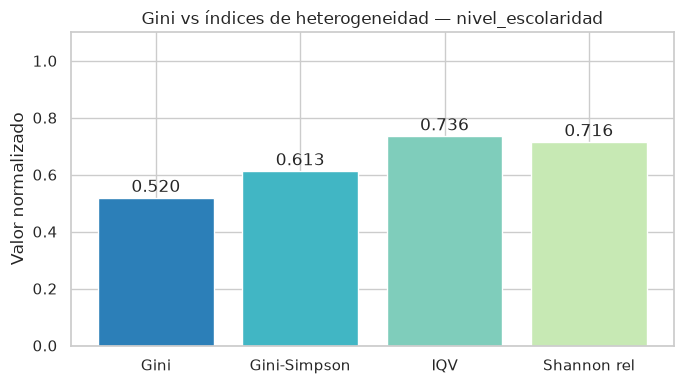

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
metricas = ["Gini", "Gini-Simpson", "IQV", "Shannon rel"]
valores = [g, gs, q, h / hmax]
colores = ["#2c7fb8", "#41b6c4", "#7fcdbb", "#c7e9b4"]
bars = ax.bar(metricas, valores, color=colores)
for b, v in zip(bars, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor normalizado")
ax.set_title("Gini vs índices de heterogeneidad — nivel_escolaridad")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "05_gini_vs_entropia.png", dpi=150)
plt.show()